In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [5]:
df = pd.read_csv("Social_Network_Ads.csv" ) 

df = df.iloc[:, 2:]

print("Shape:", df.shape)
print("\n Sample Data:")
print(df.head())
print("\n Data Types:")
print(df.dtypes)
print("\n Basic statistics:")
print(df.describe().round(1))

Shape: (400, 3)

 Sample Data:
   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0

 Data Types:
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object

 Basic statistics:
         Age  EstimatedSalary  Purchased
count  400.0            400.0      400.0
mean    37.7          69742.5        0.4
std     10.5          34097.0        0.5
min     18.0          15000.0        0.0
25%     29.8          43000.0        0.0
50%     37.0          70000.0        0.0
75%     46.0          88000.0        1.0
max     60.0         150000.0        1.0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1),
    df['Purchased'],
    test_size = 0.3,
    random_state = 42
)

In [10]:
print("Train set shape :", X_train.shape)
print("Test set shape :", X_test.shape)
print("Before training statistics:")
print(np.round(X_train.describe(),1))

Train set shape : (280, 2)
Test set shape : (120, 2)
Before training statistics:
         Age  EstimatedSalary
count  280.0            280.0
mean    37.6          70589.3
std     10.2          33948.5
min     18.0          15000.0
25%     30.0          44000.0
50%     37.0          71000.0
75%     45.0          88000.0
max     60.0         150000.0


In [14]:
# Standardization
scaler = StandardScaler()

# STEP 1 : fit the scaler on the training data (calculate mean and std)
scaler.fit(X_train)

print("Mean learned from the training data:")
print(f" Age Mean : {scaler.mean_[0]:.2f}")
print(f" Estimated Salary Mean : {scaler.mean_[1]:.2f}")

# STEP 2 : transform both train and test using SAME scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 3 : convert back to dataframe with column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Compare before and after scaling
print("\n BEFORE SCALING : ")
print(np.round(X_train.describe(),1))

print("AFTER SCALING : ")
print(np.round(X_train_scaled.describe(),1))

Mean learned from the training data:
 Age Mean : 37.58
 Estimated Salary Mean : 70589.29

 BEFORE SCALING : 
         Age  EstimatedSalary
count  280.0            280.0
mean    37.6          70589.3
std     10.2          33948.5
min     18.0          15000.0
25%     30.0          44000.0
50%     37.0          71000.0
75%     45.0          88000.0
max     60.0         150000.0
AFTER SCALING : 
         Age  EstimatedSalary
count  280.0            280.0
mean    -0.0              0.0
std      1.0              1.0
min     -1.9             -1.6
25%     -0.7             -0.8
50%     -0.1              0.0
75%      0.7              0.5
max      2.2              2.3


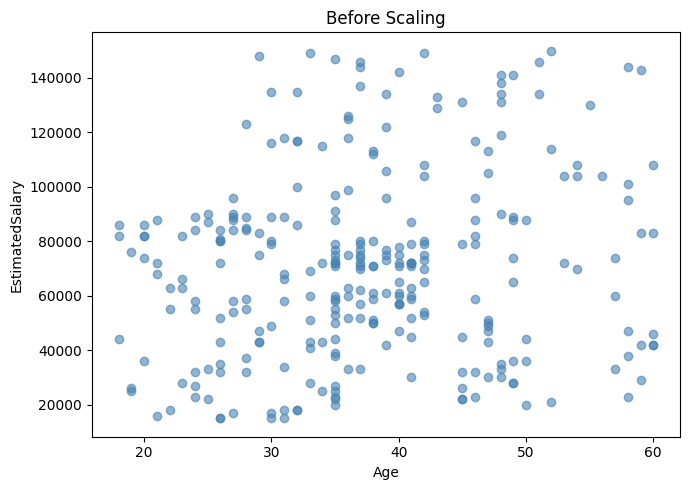

In [15]:
# Before scaling
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(X_train['Age'], X_train['EstimatedSalary'],
           color='steelblue', alpha=0.6)
ax.set_title("Before Scaling")
ax.set_xlabel("Age")
ax.set_ylabel("EstimatedSalary")
plt.tight_layout()
plt.show()

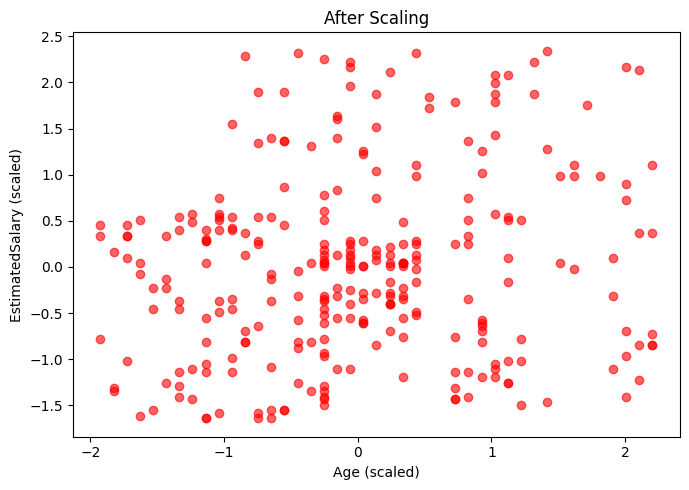

In [16]:
# After scaling
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],
           color='red', alpha=0.6)
ax.set_title("After Scaling")
ax.set_xlabel("Age (scaled)")
ax.set_ylabel("EstimatedSalary (scaled)")
plt.tight_layout()
plt.show()

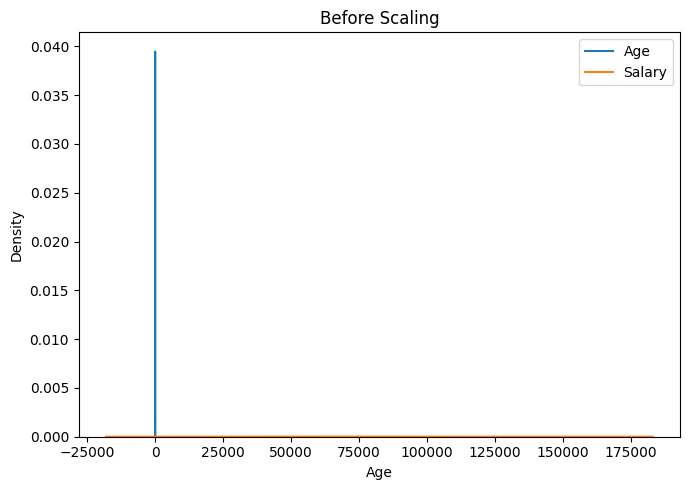

In [18]:
# KDE before  scaling
fig, ax = plt.subplots(figsize=(7, 5))

sns.kdeplot(X_train['Age'],             ax=ax, label='Age')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax, label='Salary')
ax.set_title('Before Scaling')
ax.legend()
plt.tight_layout()
plt.show()

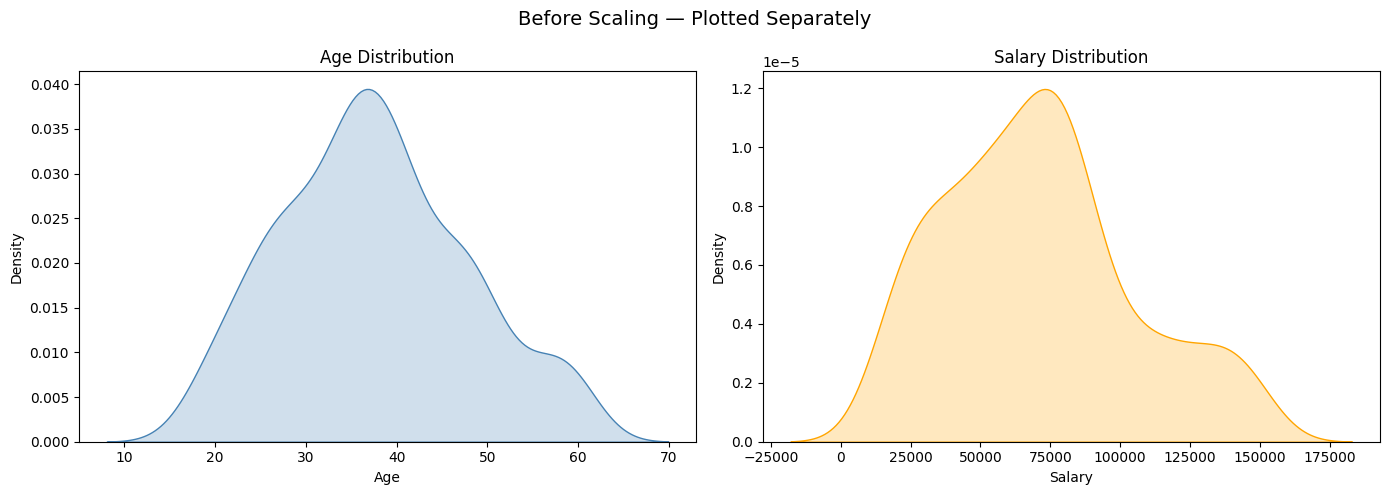

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Before Scaling — Plotted Separately", fontsize=14)

# Age on its own scale
sns.kdeplot(X_train['Age'],
            ax=axes[0],
            color='steelblue',
            fill=True)
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

# Salary on its own scale
sns.kdeplot(X_train['EstimatedSalary'],
            ax=axes[1],
            color='orange',
            fill=True)
axes[1].set_title("Salary Distribution")
axes[1].set_xlabel("Salary")

plt.tight_layout()
plt.show()

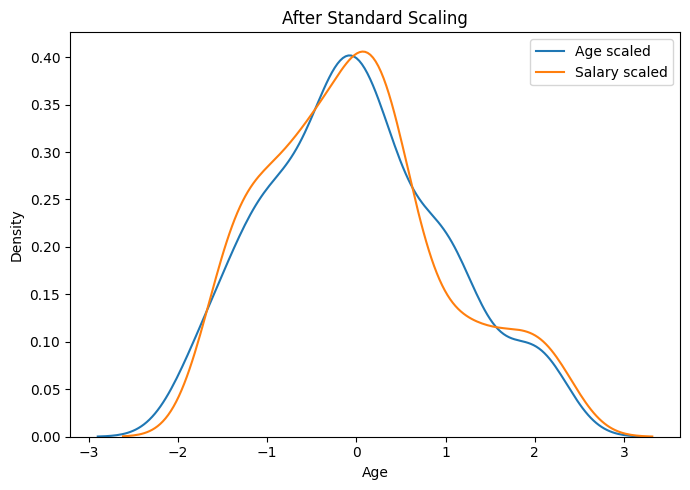

In [19]:
# KDE after scaling
fig, ax = plt.subplots(figsize=(7, 5))

sns.kdeplot(X_train_scaled['Age'],             ax=ax, label='Age scaled')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax, label='Salary scaled')
ax.set_title('After Standard Scaling')
ax.legend()
plt.tight_layout()
plt.show()

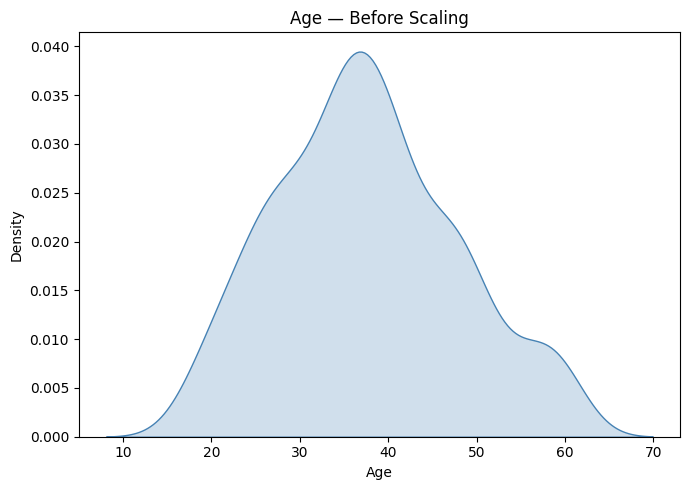

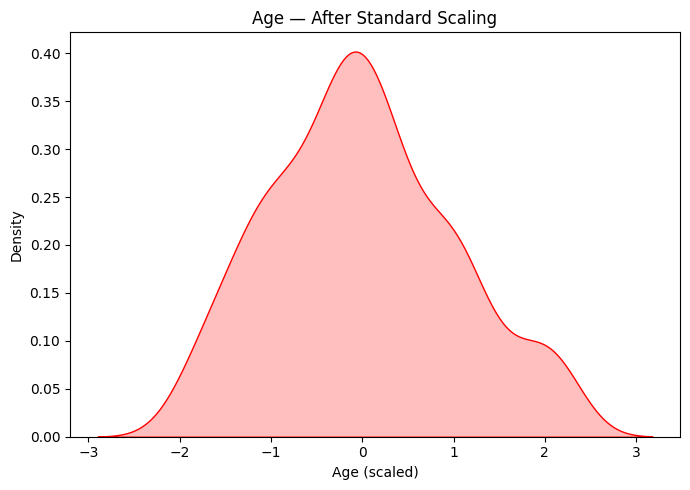

In [21]:
# Age before scaling
fig, ax = plt.subplots(figsize=(7, 5))

sns.kdeplot(X_train['Age'], ax=ax, color='steelblue', fill=True)
ax.set_title('Age — Before Scaling')
ax.set_xlabel('Age')
plt.tight_layout()
plt.show()

# Age after scaling
fig, ax = plt.subplots(figsize=(7, 5))

sns.kdeplot(X_train_scaled['Age'], ax=ax, color='red', fill=True)
ax.set_title('Age — After Standard Scaling')
ax.set_xlabel('Age (scaled)')
plt.tight_layout()
plt.show()

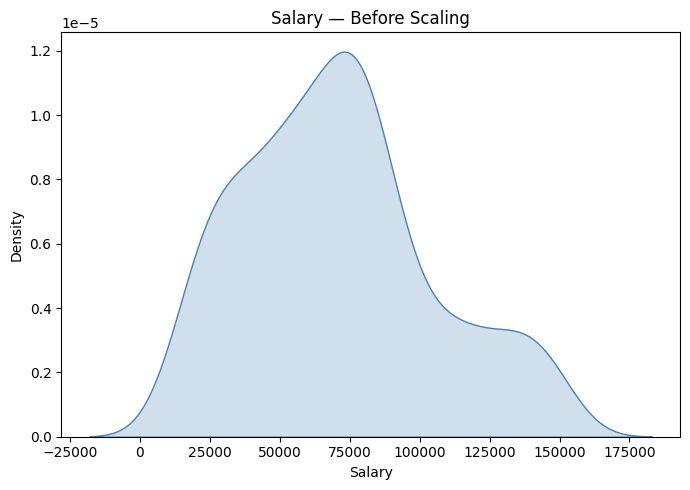

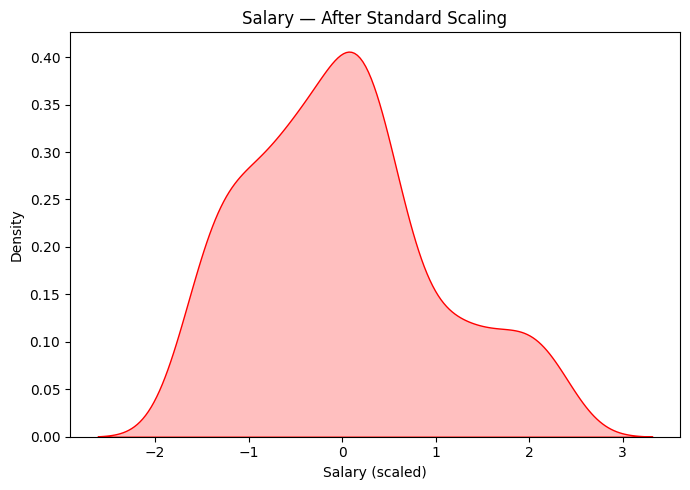

In [22]:
# Salary before scaling 
fig, ax = plt.subplots(figsize=(7, 5))

sns.kdeplot(X_train['EstimatedSalary'], ax=ax, color='steelblue', fill=True)
ax.set_title('Salary — Before Scaling')
ax.set_xlabel('Salary')
plt.tight_layout()
plt.show()

# Salary after scaling
fig, ax = plt.subplots(figsize=(7, 5))

sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax, color='red', fill=True)
ax.set_title('Salary — After Standard Scaling')
ax.set_xlabel('Salary (scaled)')
plt.tight_layout()
plt.show()

In [25]:
# ── LOGISTIC REGRESSION ────────────────────────────────────
# Logistic Regression IS affected by scaling
# (it uses distance-based calculations internally)

lr        = LogisticRegression()
lr_scaled = LogisticRegression()

lr.fit(X_train, y_train)               # without scaling
lr_scaled.fit(X_train_scaled, y_train) # with scaling

y_pred        = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

print("LOGISTIC REGRESSION:")
print(f"  Without scaling : {accuracy_score(y_test, y_pred):.4f}  ❌")
print(f"  With scaling    : {accuracy_score(y_test, y_pred_scaled):.4f}  ✅")
print(f"  Improvement     : +{(accuracy_score(y_test,y_pred_scaled) - accuracy_score(y_test,y_pred))*100:.1f}%")

print()

# ── DECISION TREE ──────────────────────────────────────────
# Decision Tree is NOT affected by scaling
# (it splits on values, not distances)

dt        = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

dt.fit(X_train, y_train)
dt_scaled.fit(X_train_scaled, y_train)

y_pred        = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

print("DECISION TREE:")
print(f"  Without scaling : {accuracy_score(y_test, y_pred):.4f}")
print(f"  With scaling    : {accuracy_score(y_test, y_pred_scaled):.4f}")
print(f"  Difference      : {(accuracy_score(y_test,y_pred_scaled) - accuracy_score(y_test,y_pred))*100:.1f}%  (no change expected)")

LOGISTIC REGRESSION:
  Without scaling : 0.8500  ❌
  With scaling    : 0.8500  ✅
  Improvement     : +0.0%

DECISION TREE:
  Without scaling : 0.8583
  With scaling    : 0.8417
  Difference      : -1.7%  (no change expected)


Original rows : 400
With outliers : 403


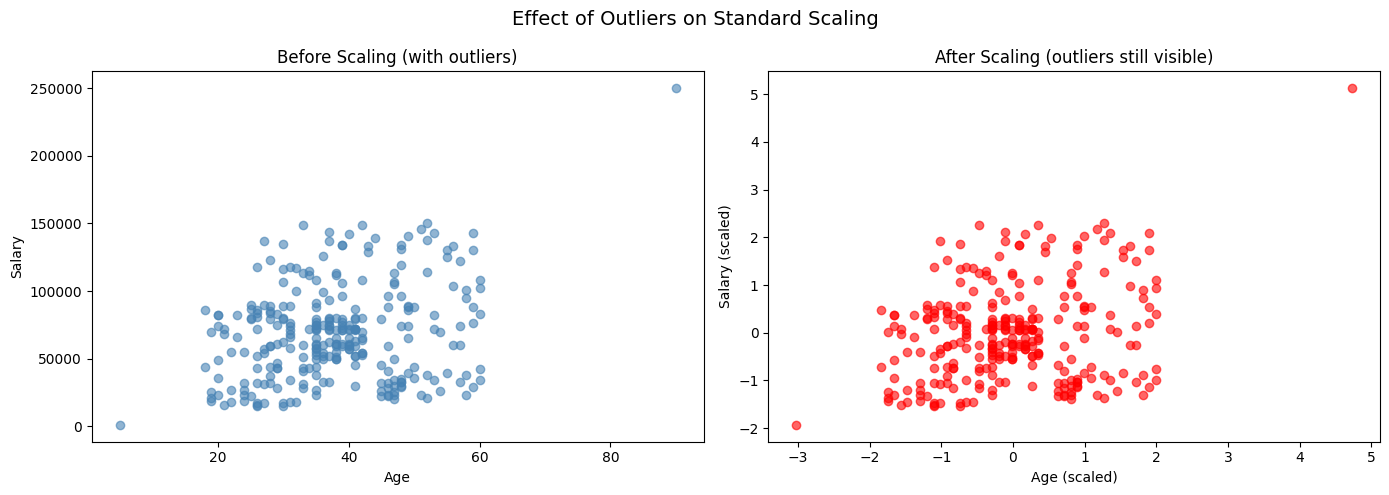


With outliers — scaled stats:
          Age  EstimatedSalary
count  282.00           282.00
mean     0.00             0.00
std      1.00             1.00
min     -3.03            -1.93
25%     -0.74            -0.74
50%     -0.10            -0.03
75%      0.72             0.50
max      4.73             5.12


In [33]:
df_outlier = df.copy()
outliers   = pd.DataFrame({
    'Age'            : [5,  90,  95],
    'EstimatedSalary': [1000, 250000, 350000],
    'Purchased'      : [0, 1, 1]
})
df_outlier = pd.concat([df_outlier, outliers], ignore_index=True)

print(f"Original rows : {len(df)}")
print(f"With outliers : {len(df_outlier)}")

# ── split and scale with outliers ─────────────────────────
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    df_outlier.drop('Purchased', axis=1),
    df_outlier['Purchased'],
    test_size=0.3,
    random_state=0
)

scaler_o        = StandardScaler()
scaler_o.fit(X_train_o)
X_train_o_scaled = pd.DataFrame(
    scaler_o.transform(X_train_o),
    columns=X_train_o.columns
)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 5))
fig.suptitle("Effect of Outliers on Standard Scaling", fontsize=14)

ax1.scatter(X_train_o['Age'], X_train_o['EstimatedSalary'],
            color='steelblue', alpha=0.6)
ax1.set_title("Before Scaling (with outliers)")
ax1.set_xlabel("Age")
ax1.set_ylabel("Salary")

ax2.scatter(X_train_o_scaled['Age'], X_train_o_scaled['EstimatedSalary'],
            color='red', alpha=0.6)
ax2.set_title("After Scaling (outliers still visible)")
ax2.set_xlabel("Age (scaled)")
ax2.set_ylabel("Salary (scaled)")

plt.tight_layout()
plt.show()

print("\nWith outliers — scaled stats:")
print(np.round(X_train_o_scaled.describe(), 2))

In [34]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler

scalers = {
    "StandardScaler" : StandardScaler(),
    "MinMaxScaler"   : MinMaxScaler(),
    "RobustScaler"   : RobustScaler()   # uses median and IQR → outlier proof
}

print(f"{'Scaler':<20} {'Age_mean':>10} {'Age_std':>10} {'Sal_mean':>10} {'Sal_std':>10}")
print("-" * 60)

for name, s in scalers.items():
    s.fit(X_train_o)
    scaled = pd.DataFrame(s.transform(X_train_o), columns=X_train_o.columns)
    print(f"{name:<20} {scaled['Age'].mean():>10.3f} "
          f"{scaled['Age'].std():>10.3f} "
          f"{scaled['EstimatedSalary'].mean():>10.3f} "
          f"{scaled['EstimatedSalary'].std():>10.3f}")

Scaler                 Age_mean    Age_std   Sal_mean    Sal_std
------------------------------------------------------------
StandardScaler            0.000      1.002      0.000      1.002
MinMaxScaler              0.390      0.129      0.274      0.142
RobustScaler              0.072      0.686      0.026      0.808
